<a href="https://colab.research.google.com/github/PedroDuarteMachado/Linguagens_De_Programacao/blob/main/Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo global do Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Geração de dados sintéticos
np.random.seed(101)
n = 300

dados = {
    'idade': np.random.normal(35, 10, n).astype(int),
    'plano': np.random.choice(['Gratuito', 'Básico', 'Pro'], n, p=[0.5, 0.3, 0.2]),
    'tempo_uso_horas': np.random.uniform(1, 50, n),
    'bugs_reportados': np.random.poisson(2, n),
    'satisfacao': np.random.randint(1, 11, n)
}

df_sistema = pd.DataFrame(dados)

# Ajustando regras de negócio sintéticas para gerar correlações visuais
df_sistema.loc[df_sistema['plano'] == 'Pro', 'tempo_uso_horas'] += 15
df_sistema.loc[df_sistema['plano'] == 'Pro', 'satisfacao'] += 2
df_sistema['satisfacao'] = df_sistema['satisfacao'] - (df_sistema['bugs_reportados'] * 0.5)
df_sistema['satisfacao'] = df_sistema['satisfacao'].clip(1, 10).astype(int)
df_sistema['idade'] = df_sistema['idade'].clip(18, 70)

df_sistema.head()

,idade,plano,tempo_uso_horas,bugs_reportados,satisfacao
0,62,Gratuito,14.165127,3,1
1,41,Básico,19.076874,1,2
2,44,Básico,28.574818,3,6
3,40,Gratuito,28.898728,3,6
4,41,Básico,6.566953,1,2


**1º ETAPA**

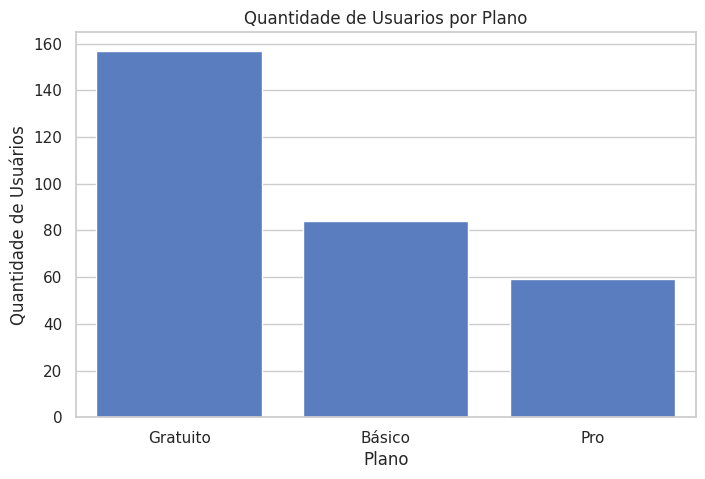

In [ ]:
plt.figure(figsize=(8, 5))

ordem = df_sistema['plano'].value_counts().index

sns.countplot(
    data=df_sistema,
    x='plano',
    order=ordem
)

plt.title('Quantidade de Usuarios por Plano')
plt.xlabel('Plano')
plt.ylabel('Quantidade de Usuários')

plt.show()

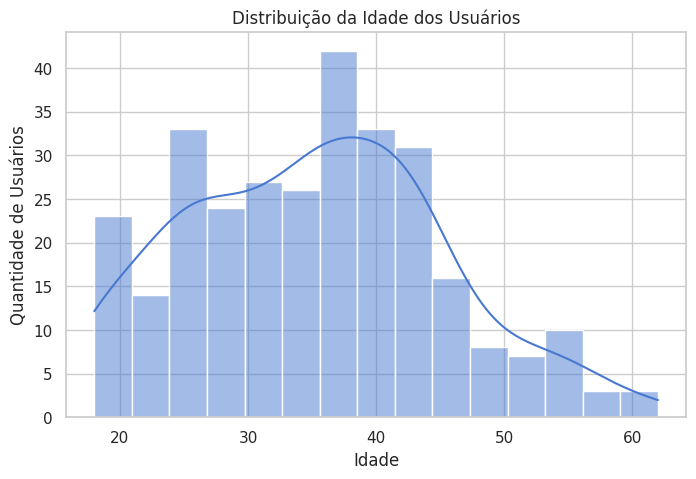

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_sistema,
    x='idade',
    kde='True',
    bins=15
)

plt.title('Distribuição da Idade dos Usuários')
plt.xlabel('Idade')
plt.ylabel('Quantidade de Usuários')

plt.show()

**2º ETAPA**

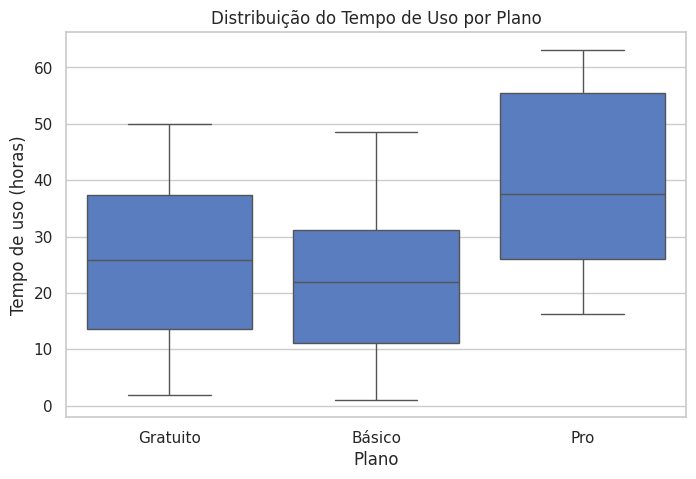

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_sistema,
    x='plano',
    y='tempo_uso_horas'
)

plt.title('Distribuição do Tempo de Uso por Plano')
plt.xlabel('Plano')
plt.ylabel('Tempo de uso (horas)')

plt.show()

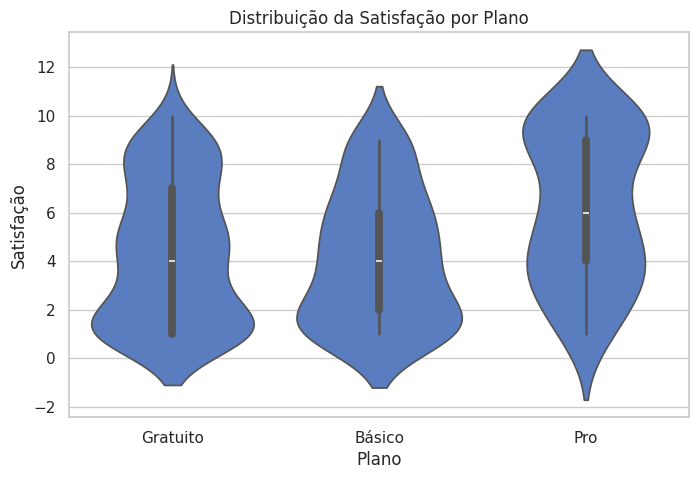

In [ ]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df_sistema,
    x='plano',
    y='satisfacao'
)

plt.title('Distribuição da Satisfação por Plano')
plt.xlabel('Plano')
plt.ylabel('Satisfação')

plt.show()

**3º ETAPA**

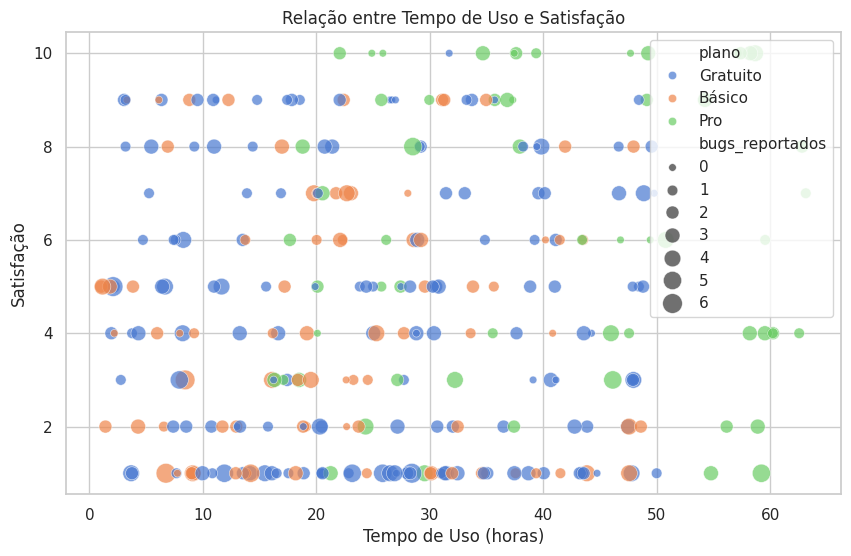

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data= df_sistema,
    x='tempo_uso_horas',
    y='satisfacao',
    hue='plano',
    size='bugs_reportados',
    sizes=(30,200),
    alpha=0.7
)

plt.title('Relação entre Tempo de Uso e Satisfação')
plt.xlabel('Tempo de Uso (horas)')
plt.ylabel('Satisfação')

plt.show()


                    idade  tempo_uso_horas  bugs_reportados  satisfacao
idade            1.000000        -0.041905         0.059112   -0.046303
tempo_uso_horas -0.041905         1.000000        -0.034809    0.081600
bugs_reportados  0.059112        -0.034809         1.000000   -0.219174
satisfacao      -0.046303         0.081600        -0.219174    1.000000


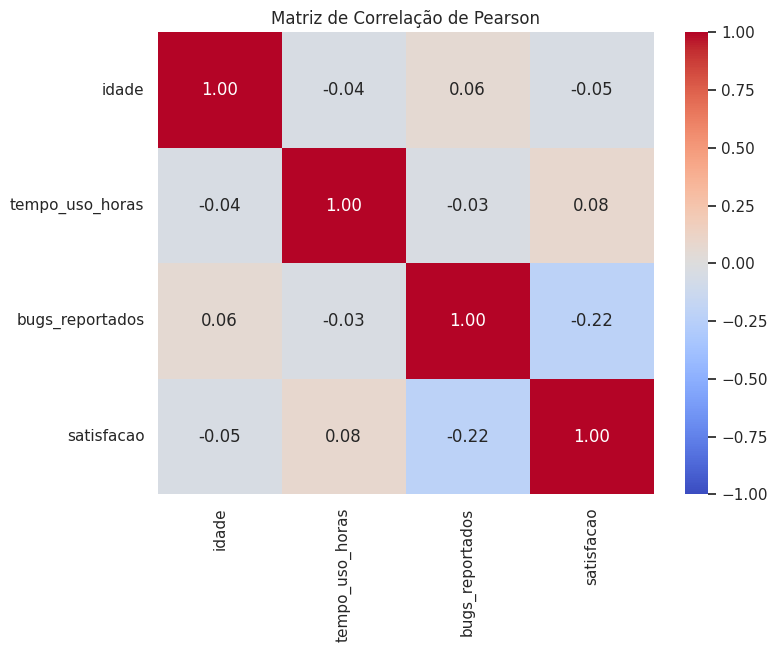

In [ ]:
df_numerico = df_sistema.select_dtypes(include='number')

correlacao = df_numerico.corr(method='pearson')

print(correlacao)

plt.figure(figsize=(8,6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title('Matriz de Correlação de Pearson')

plt.show()

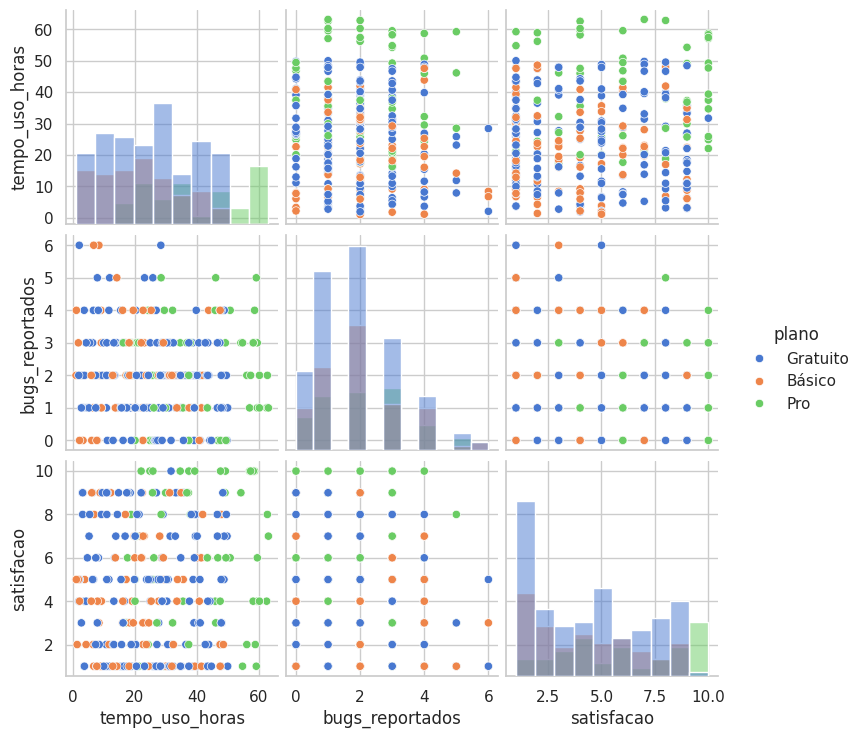

In [ ]:
sns.pairplot(
    df_sistema[
        ['tempo_uso_horas', 'bugs_reportados', 'satisfacao', 'plano']
    ],
    hue='plano',
    diag_kind='hist'
)

plt.show()